# Day 8 — 자율 프로젝트: 나만의 모델 서빙 서비스 만들기

## 2 모델 준비

### 2.1 모델 선택 및 로드

In [1]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"GPU 사용 가능: {torch.cuda.is_available()}")

PyTorch: 2.7.1+cu118
GPU 사용 가능: True


In [2]:
from dotenv import load_dotenv
import os

env_path = "..\.env"
load_dotenv(env_path)

print("HF_TOKEN loaded:", os.getenv("HF_TOKEN") is not None)
HF_TOKEN                               = os.getenv("HF_TOKEN")
os.environ["HUGGINGFACEHUB_API_TOKEN"] = HF_TOKEN  # 환경 변수로도 올림

HF_TOKEN loaded: True


In [4]:
# pip install "transformers>=4.38.0,<4.45.0" "tokenizers>=0.15.0,<0.20.0" "sentencepiece"

In [3]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

MODEL_NAME = "eenzeenee/t5-base-korean-summarization"
print(f"모델: {MODEL_NAME}")

cache_dir = r".\cache"  # 1단계에서 삭제했으므로 새로 생성될 것입니다.
device = "cuda" if torch.cuda.is_available() else "cpu"

# 에러를 피하기 위해 가장 깔끔한 상태로 로드
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    cache_dir=cache_dir,
    use_fast=True,         # Slow 버전의 경로 에러를 피하기 위해 Fast 사용
    local_files_only=False
)

model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME,
    cache_dir=cache_dir,
    use_safetensors=True
)

model = model.to(device)
model.eval()

print(f"✅ 모델 로드 완료! (Device: {device})")
print(f"파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

D:\NiceDay\k\python\aiffel\model-serving-course\.venv_af2\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

D:\NiceDay\k\python\aiffel\model-serving-course\.venv_af2\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in D:\NiceDay\K\python\aiffel\model-serving-course\my_project\cache\models--eenzeenee--t5-base-korean-summarization. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


config.json:   0%|          | 0.00/782 [00:00<?, ?B/s]

D:\NiceDay\k\python\aiffel\model-serving-course\.venv_af2\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/1.10G [00:00<?, ?B/s]

✅ 드디어 로드 완료! (Device: cuda)


In [5]:
import math
import textwrap

def summarize_text(text: str,
                   max_input_len: int = 512,
                   max_summary_len: int = 128) -> str:
    """
    긴 한국어 텍스트를 요약문으로 변환
    """
    # T5 스타일: 태스크 프리픽스 사용 (모델 README에서도 요약 태스크로 사용) [web:214]
    prefix = "summarize: "
    input_text = prefix + text.strip()

    inputs = tokenizer(
        input_text,
        max_length=max_input_len,
        truncation=True,
        return_tensors="pt",
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_length=max_summary_len,
            min_length=10,
            num_beams=4,
            do_sample=False,  # 일단 결정적 요약
            no_repeat_ngram_size=3,
        )

    summary = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return summary.strip()

def chunk_text(text: str, max_chars: int = 1500):
    """
    아주 단순하게 문자 길이 기준으로 문서를 여러 chunk로 나눔.
    (문장 단위로 나누고 싶으면 nltk, kss 등을 사용해도 됨)
    """
    text = text.strip()
    if len(text) <= max_chars:
        return [text]

    chunks = []
    start = 0
    while start < len(text):
        end = start + max_chars
        chunks.append(text[start:end])
        start = end
    return chunks

def summarize_long_text(text: str,
                        chunk_chars: int = 1500,
                        max_input_len: int = 512,
                        max_summary_len: int = 128) -> str:
    # 1차: chunk별 요약
    chunks = chunk_text(text, max_chars=chunk_chars)
    partial_summaries = []
    for i, ch in enumerate(chunks, 1):
        print(f"[{i}/{len(chunks)}] chunk 요약 중...")
        partial = summarize_text(ch, max_input_len=max_input_len, max_summary_len=max_summary_len)
        partial_summaries.append(partial)

    # 2차: 부분 요약들을 합쳐 최종 요약
    combined = "\n".join(partial_summaries)
    final_summary = summarize_text(combined,
                                   max_input_len=max_input_len,
                                   max_summary_len=max_summary_len)
    return final_summary

def summarize_long_file(path: str) -> str:
    with open(path, "r", encoding="utf-8") as f:
        text = f.read()
    return summarize_long_text(text)


In [6]:
input_path = "data\sample1.txt"
summary = summarize_long_file(input_path)
print("==== 최종 요약 ====")
print(summary)

[1/4] chunk 요약 중...
[2/4] chunk 요약 중...
[3/4] chunk 요약 중...
[4/4] chunk 요약 중...
==== 최종 요약 ====
걷기 운동으로 아밀로이드 축적을 억제할 수 있다는 사실이 세계 최초로 밝혀졌다.


In [ ]:
sample = "..."  # 긴 한국어 문단
prefix = "summarize: "  # T5 스타일의 태스크 프리픽스

inputs = tokenizer(prefix + sample, max_length=512, truncation=True, return_tensors="pt")
outputs = model.generate(
    **inputs,
    num_beams=3,
    do_sample=True,
    min_length=10,
    max_length=64
)
summary = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

## 3. 프로젝트 뼈대 코드

### 3.1 폴더 구조

In [5]:
import os

folders = ["app", "models", "frontend", "texts", "cache"]
for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"✅ {folder}/ 생성 완료")

✅ app/ 생성 완료
✅ models/ 생성 완료
✅ frontend/ 생성 완료
✅ texts/ 생성 완료
✅ cache/ 생성 완료


In [2]:
!dir

 D 드라이브의 볼륨에는 이름이 없습니다.
 볼륨 일련 번호: F9E4-F73F

 D:\NiceDay\K\python\aiffel\model-serving-course\my_project 디렉터리

2026-04-07  오전 10:50    <DIR>          .
2026-04-07  오전 10:26    <DIR>          ..
2026-04-07  오전 10:37    <DIR>          .ipynb_checkpoints
2026-04-07  오전 10:50    <DIR>          app
2026-04-07  오전 10:50    <DIR>          data
2026-04-07  오전 10:50    <DIR>          frontend
2026-04-07  오전 10:50    <DIR>          models
2026-04-07  오전 10:37             1,972 Untitled.ipynb
               1개 파일               1,972 바이트
               7개 디렉터리  74,435,178,496 바이트 남음


### 3.2 auth.py — 재사용

In [3]:
%%writefile app/auth.py
"""
Day 6에서 만든 인증 모듈을 그대로 재사용합니다.
"""
from fastapi import HTTPException, Header

VALID_API_KEYS = {
    "test-key-001": "사용자A",
    "test-key-002": "사용자B",
}


async def verify_api_key(x_api_key: str = Header(None)) -> str:
    if x_api_key is None:
        raise HTTPException(
            status_code=401,
            detail="API Key가 필요합니다. X-API-Key 헤더를 포함해 주세요.",
        )
    if x_api_key not in VALID_API_KEYS:
        raise HTTPException(
            status_code=401,
            detail="유효하지 않은 API Key입니다.",
        )
    return VALID_API_KEYS[x_api_key]

Writing app/auth.py


### 3.3 schemas.py — 직접 작성

"""
입력/출력 스키마를 정의하세요.

참고: Day 2 섹션 4 (Pydantic 기초), Day 5 섹션 3 (HousingRequest)

TODO:
  - 본인의 모델 입력에 맞는 Request 스키마를 정의하세요.
  - 모델 출력에 맞는 Response 스키마를 정의하세요.
  - 필수 필드와 선택 필드를 구분하세요.
  - 적절한 검증 규칙(타입, 범위, 길이 등)을 추가하세요.

예시 (텍스트 분류의 경우):
  class PredictRequest(BaseModel):
      text: str = Field(..., min_length=1, max_length=5000)

  class PredictResponse(BaseModel):
      success: bool
      label: str
      confidence: float
"""

In [8]:
%%writefile app/schemas.py

from pydantic import BaseModel, Field

class FileListResponse(BaseModel):
    files: list[str] = Field(default_factory=list, description="요약 가능한 파일 목록 (.txt)")


class SummarizeRequest(BaseModel):
    filename: str = Field(..., description="요약할 파일 이름 (TEXT_DIR 아래)")


class SummarizeResponse(BaseModel):
    filename: str = Field(..., description="요약된 파일 이름")
    summary: str = Field(..., description="생성된 요약 텍스트")


Writing app/schemas.py


### 3.4 model_service.py — 직접 작성

"""
모델 로드와 추론 함수를 정의하세요.

참고: Day 1 섹션 5 (모델 로드), Day 5 섹션 2 (HousingPredictor)

TODO:
  1. load_model(): 모델을 로드하여 반환합니다.
     - transformers의 pipeline() 또는 from_pretrained()을 사용합니다.
     - 섹션 2.3에서 확인한 코드를 여기에 옮기면 됩니다.

  2. predict(model, input_data): 입력을 받아 추론 결과를 반환합니다.
     - 입력 전처리가 필요하면 여기서 합니다.
     - 결과를 dict로 반환합니다.

예시 (텍스트 분류의 경우):
  def load_model():
      return pipeline("text-classification", model="모델이름")

  def predict(model, text: str) -> dict:
      result = model(text)
      return {"label": result[0]["label"], "confidence": result[0]["score"]}
"""

In [4]:
%%writefile app/model_service.py

from pathlib import Path
from typing import List

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

from .schemas import SummarizeResponse

MODEL_NAME = "eenzeenee/t5-base-korean-summarization"
TEXT_DIR = Path("./texts")  # 텍스트 파일 디렉터리 
CACHE_DIR = r".\cache"

class SummarizationService:
    def __init__(self, model_name: str = MODEL_NAME):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        print("🔄 SummarizationService: 모델 로딩 중...")
        self.tokenizer = AutoTokenizer.from_pretrained(
            model_name,
            cache_dir=CACHE_DIR,
            use_fast=True,         # Slow 버전의 경로 에러를 피하기 위해 Fast 사용
            local_files_only=False
        )
        
        self.model = AutoModelForSeq2SeqLM.from_pretrained(
            model_name,
            cache_dir=CACHE_DIR,
            use_safetensors=True
        )

        self.model = self.model.to(self.device)
        self.model.eval()

        self.model_name = model_name
        print("✅ SummarizationService: 모델 로드 완료")

        # 디렉터리 보장
        TEXT_DIR.mkdir(parents=True, exist_ok=True)

    # --------- 내부 유틸 메서드들 --------- #

    def _summarize_text(
        self,
        text: str,
        max_input_len: int = 512,
        max_summary_len: int = 128,
    ) -> str:
        prefix = "summarize: "
        input_text = prefix + text.strip()

        inputs = self.tokenizer(
            input_text,
            max_length=max_input_len,
            truncation=True,
            return_tensors="pt",
        )
        inputs = {k: v.to(self.device) for k, v in inputs.items()}

        with torch.no_grad():
            output_ids = self.model.generate(
                **inputs,
                max_length=max_summary_len,
                min_length=10,
                num_beams=4,
                do_sample=False,
                no_repeat_ngram_size=3,
            )

        summary = self.tokenizer.decode(output_ids[0], skip_special_tokens=True)
        return summary.strip()

    @staticmethod
    def _chunk_text(text: str, max_chars: int = 1500) -> List[str]:
        text = text.strip()
        if len(text) <= max_chars:
            return [text]

        chunks: List[str] = []
        start = 0
        while start < len(text):
            end = start + max_chars
            chunks.append(text[start:end])
            start = end
        return chunks

    def _summarize_long_text(
        self,
        text: str,
        chunk_chars: int = 1500,
        max_input_len: int = 512,
        max_summary_len: int = 128,
    ) -> str:
        chunks = self._chunk_text(text, max_chars=chunk_chars)
        partial_summaries: List[str] = []

        for i, ch in enumerate(chunks, 1):
            print(f"[{i}/{len(chunks)}] chunk 요약 중...")
            partial = self._summarize_text(
                ch,
                max_input_len=max_input_len,
                max_summary_len=max_summary_len,
            )
            partial_summaries.append(partial)

        combined = "\n".join(partial_summaries)
        final_summary = self._summarize_text(
            combined,
            max_input_len=max_input_len,
            max_summary_len=max_summary_len,
        )
        return final_summary

    # --------- 외부에 노출되는 서비스 메서드 --------- #

    def list_text_files(self) -> list[str]:
        """TEXT_DIR 아래 .txt 파일 목록 반환"""
        return [
            f.name
            for f in TEXT_DIR.iterdir()
            if f.is_file() and f.suffix.lower() == ".txt"
        ]

    def summarize_file(self, filename: str) -> SummarizeResponse:
        """파일을 읽어서 요약 후 SummarizeResponse 반환"""
        file_path = TEXT_DIR / filename

        if not file_path.exists() or not file_path.is_file():
            raise FileNotFoundError(f"File not found: {filename}")

        try:
            with open(file_path, "r", encoding="utf-8") as f:
                text = f.read()
        except UnicodeDecodeError:
            with open(file_path, "r", encoding="cp949", errors="ignore") as f:
                text = f.read()

        summary = self._summarize_long_text(text)
        return SummarizeResponse(filename=filename, summary=summary)



Overwriting app/model_service.py


### 3.5 main.py — 직접 작성

In [13]:
"""
FastAPI 서버를 정의하세요.

참고: Day 5 섹션 3 (housing_api.py), Day 6 섹션 6 (image_api.py)

TODO:
  1. FastAPI 앱 생성
  2. startup 이벤트에서 모델 로드
  3. GET /health 엔드포인트
  4. POST /predict 엔드포인트
     - Pydantic 스키마로 입력 검증
     - Depends(verify_api_key)로 인증 적용
     - run_in_executor로 비동기 추론

필수 import:
  import asyncio
  from concurrent.futures import ThreadPoolExecutor
  from fastapi import FastAPI, Depends, HTTPException
  from app.auth import verify_api_key
  from app.schemas import PredictRequest, PredictResponse  (본인이 정의한 이름)
  from app.model_service import load_model, predict
"""

'\nFastAPI 서버를 정의하세요.\n\n참고: Day 5 섹션 3 (housing_api.py), Day 6 섹션 6 (image_api.py)\n\nTODO:\n  1. FastAPI 앱 생성\n  2. startup 이벤트에서 모델 로드\n  3. GET /health 엔드포인트\n  4. POST /predict 엔드포인트\n     - Pydantic 스키마로 입력 검증\n     - Depends(verify_api_key)로 인증 적용\n     - run_in_executor로 비동기 추론\n\n필수 import:\n  import asyncio\n  from concurrent.futures import ThreadPoolExecutor\n  from fastapi import FastAPI, Depends, HTTPException\n  from app.auth import verify_api_key\n  from app.schemas import PredictRequest, PredictResponse  (본인이 정의한 이름)\n  from app.model_service import load_model, predict\n'

In [20]:
%%writefile app/main.py
"""
Day 8 - 한국어 요약 서비스 FastAPI 서버
"""
    
import asyncio
from concurrent.futures import ThreadPoolExecutor

from fastapi import FastAPI, Depends, HTTPException, status

from app.schemas import FileListResponse, SummarizeRequest, SummarizeResponse
from app.model_service import SummarizationService

from app.auth import verify_api_key
from app.logger_config import setup_logger
from app.error_handlers import register_error_handlers
from app.middleware import RequestLoggingMiddleware

MODEL_NAME = "eenzeenee/t5-base-korean-summarization"

# ===== 설정 =====

logger = setup_logger("sumup_main")

app = FastAPI(
    title="Korean T5 Sum up API",
    description="한국어 T5 기반 텍스트 요약 API (인증 필요)",
    version="1.0.0",
)

app.add_middleware(RequestLoggingMiddleware)
register_error_handlers(app)

inference_executor = ThreadPoolExecutor(max_workers=2, thread_name_prefix="sumup")

# ===== 모델 로드 =====
sumup = None

@app.on_event("startup")
async def startup():
    global sumup
    import torch
    model_name = MODEL_NAME
    logger.info(f"Text 요약 모델 로드 중: {model_name}")
    sumup = SummarizationService(model_name)                
    logger.info("모델 로드 완료")


# def run_chat(messages, max_new_tokens, temperature):
#     """별도 스레드에서 실행되는 추론 함수"""
#     if sumup is None:
#         raise RuntimeError("모델이 로드되지 않았습니다")
#     return sumup.generate_response(
#         messages=[m.model_dump() for m in messages],
#         max_new_tokens=max_new_tokens,
#         temperature=temperature,
#     )


# ===== 엔드포인트 =====

@app.get("/health", tags=["System"])
async def health_check():
    return {
        "status": "healthy" if sumup else "loading",
        "model": sumup.model_name if sumup else None,
    }

@app.get("/files", response_model=FileListResponse)
async def list_files(
    user: str = Depends(verify_api_key),
):
    files = sumup.list_text_files()
    return FileListResponse(files=files)

@app.post("/summarize", response_model=SummarizeResponse, status_code=status.HTTP_200_OK)
async def summarize(
    req: SummarizeRequest,
    user: str = Depends(verify_api_key),
):
    try:
        return sumup.summarize_file(req.filename)
    except FileNotFoundError as e:
        raise HTTPException(status_code=status.HTTP_404_NOT_FOUND, detail=str(e))
    except Exception as e:
        raise HTTPException(status_code=status.HTTP_500_INTERNAL_SERVER_ERROR, detail=str(e))


Overwriting app/main.py


### 3.6 frontend/app.py — 직접 작성

In [9]:
"""
Streamlit 프론트엔드를 정의하세요.

참고: Day 4 섹션 6 (대시보드), Day 5 섹션 4 (주택 가격 UI)

TODO:
  1. st.title()로 제목
  2. 사이드바에 API Key 입력
  3. 본인의 모델에 맞는 입력 위젯 (text_input, file_uploader 등)
  4. 버튼 클릭 시 requests.post()로 API 호출
  5. 결과 표시

실행 방법:
  streamlit run frontend/app.py
"""

'\nStreamlit 프론트엔드를 정의하세요.\n\n참고: Day 4 섹션 6 (대시보드), Day 5 섹션 4 (주택 가격 UI)\n\nTODO:\n  1. st.title()로 제목\n  2. 사이드바에 API Key 입력\n  3. 본인의 모델에 맞는 입력 위젯 (text_input, file_uploader 등)\n  4. 버튼 클릭 시 requests.post()로 API 호출\n  5. 결과 표시\n\n실행 방법:\n  streamlit run frontend/app.py\n'

In [3]:
%%writefile frontend/app_sumup.py

import streamlit as st
import requests

API_BASE = "http://localhost:8000"

# ===== 페이지 설정 =====
st.set_page_config(
    page_title="T5 문서 요약기",
    page_icon="▤",
    layout="centered",
)

# ===== 사이드바 =====
with st.sidebar:
    st.header("⚙️ 설정")

    api_key = st.text_input("API Key", value="test-key-001", type="password")

    st.divider()

    # 서버 상태
    try:
        health = requests.get(f"{API_BASE}/health", timeout=3).json()
        if health.get("status") == "healthy":
            st.success(f"🟢 서버 연결됨")
            st.caption(f"모델: {health.get('model', 'N/A')}")
        else:
            st.warning("🟡 모델 로딩 중...")
    except Exception:
        st.error("🔴 서버 연결 실패")

    st.divider()

# ===== 메인 영역 =====
st.title("📄 한국어 T5 문서 요약기")
st.write("요약 파일을 선택해 보세요.")

# 1. 서버에서 파일 목록 가져오기
files = []
try:
    resp = requests.get(
        f"{API_BASE}/files",
        headers={"X-API-Key": api_key},     
        timeout=10,
    )
    if resp.status_code == 200:
        data = resp.json()
        files = data.get("files", [])
        timeout=60,   # 텍스트 생성은 시간이 걸릴 수 있음
    else:
        st.error(f"파일 목록 조회 실패: {resp.status_code} {resp.text}")
except Exception as e:
    st.error(f"서버 접속 실패: {e}")

if not files:
    st.info("요약할 .txt 파일이 없습니다. backend 쪽 TEXT_DIR 경로에 .txt 파일을 넣어주세요.")
    st.stop()

selected_file = st.selectbox("요약할 파일 선택", files)

if st.button("요약 실행"):
    with st.spinner("서버에서 요약 중..."):
        try:
            resp = requests.post(
                f"{API_BASE}/summarize",
                json={"filename": selected_file},
                headers={"X-API-Key": api_key},     
                timeout=600,
            )
        except Exception as e:
            st.error(f"요약 요청 실패: {e}")
        else:
            if resp.status_code == 200:
                data = resp.json()
                summary = data.get("summary", "")

                st.subheader("✅ 요약 결과")
                st.write(summary)

            else:
                st.error(f"요약 실패: {resp.status_code} {resp.text}")



Overwriting frontend/app_sumup.py


## 4. 서버 실행 및 테스트

Window 에서 서버 또는 streamlit 화면 kill
```
netstat -ano | findstr :8501
taskkill /PID 23352 /F
```
```
서버 kill
tasklist | findstr python
taskkill /PID 5428 /F
```
```
# # 터미널 1: 백엔드
# uvicorn app.main:app --port 8000

# # 터미널 2: 프론트엔드
# streamlit run frontend/app_sumup.py --server.port 8501
```

In [1]:
import nest_asyncio, uvicorn, threading, time
nest_asyncio.apply()

def run_server():
    uvicorn.run("app.main:app", host="0.0.0.0", port=8000)

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()
time.sleep(10)   # 모델 로드 대기 (첫 실행 시 더 오래 걸릴 수 있음)
print("✅ 서버 시작됨: http://localhost:8000")


INFO:     Started server process [11432]
INFO:     Waiting for application startup.


2026-04-07 14:27:31 INFO     [sumup_main] Text 요약 모델 로드 중: eenzeenee/t5-base-korean-summarization


D:\NiceDay\k\python\aiffel\model-serving-course\.venv_af2\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


🔄 SummarizationService: 모델 로딩 중...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
D:\NiceDay\k\python\aiffel\model-serving-course\.venv_af2\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


✅ SummarizationService: 모델 로드 완료
2026-04-07 14:27:34 INFO     [sumup_main] 모델 로드 완료


INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


✅ 서버 시작됨: http://localhost:8000


In [21]:
import requests, json

# 헬스체크
resp = requests.get("http://localhost:8000/health")
print(f"헬스체크: {resp.json()}")

헬스체크: {'status': 'healthy', 'model': 'eenzeenee/t5-base-korean-summarization'}


In [22]:
# file 목록 가져오기
files = []

resp = requests.get(
    "http://localhost:8000/files",
    headers={"X-API-Key": "test-key-001"},
    timeout=10,
)
result = resp.json()
files = result.get("files", [])
print(f"상태: {resp.status_code}")
print(f"응답: {files}")

상태: 200
응답: ['sample1.txt', 'sample2.txt']


In [23]:
# file 요약 가져오기
selected_file = "sample1.txt"

resp = requests.post(
    "http://localhost:8000/summarize",
    json={"filename": selected_file},
    headers={"X-API-Key": "test-key-001"},     
    timeout=600,
)
result = resp.json()
summary = result.get("summary", "")
print(f"상태: {resp.status_code}")
print(f"응답: {summary}")

상태: 200
응답: 걷기 운동으로 아밀로이드 축적을 억제할 수 있다는 사실이 세계 최초로 밝혀졌다.


## 5. 발표 및 회고

## 5.1 발표 항목

1. 어떤 도메인/태스크를 선택했는가?
   - 도메인 : Text Summarization (텍스트 요약)
   - 태스크 : 한국어 텍스트 요약
     
2. 어떤 모델을 사용했는가? (선택 이유)
   - MODEL_NAME = "eenzeenee/t5-base-korean-summarization"
   - 선택 이유
   - 1. 한국어 요약 전용으로 파인튜닝된 모델 (아래 3가지 한국어 데이터셋으로 파인튜닝)
        - Korean Paper Summarization Dataset (논문자료 요약)
        - Korean Book Summarization Dataset (도서자료 요약)
        - Korean Summary statement and Report Generation Dataset (요약문 및 레포트 생성 데이터)

    - 2. T5는 인코더-디코더(Encoder-Decoder) 구조의 시퀀스 투 시퀀스 모델로,
          번역·요약·생성과 같은 "입력 텍스트 → 출력 텍스트" 태스크에 가장 적합한 아키텍처

    - 3. T5-base는 약 2.2억 파라미터로, GPU 없이 CPU에서도 충분히 실시간 추론이 가능한 규모

    - 4. Hugging Face에서 쉽게 로드 및 배포 가능

    - 5. 실제 활용 사례가 많음 (벨로그, 블로그, 경진대회 등 실제 프로젝트에서 한국어 요약 모델로 많이 사용)

3-1. 데모 시연 (Swagger UI)

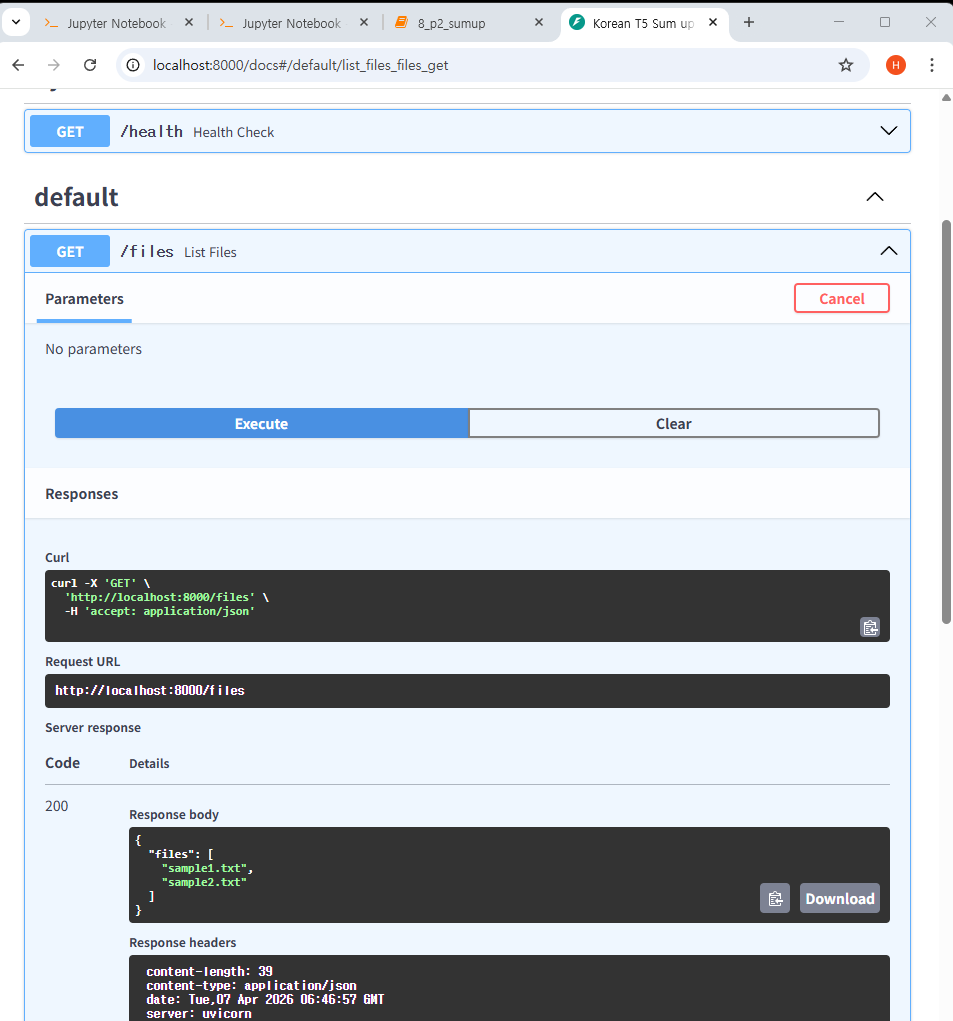

3-2. 데모 시연 (Streamlit)

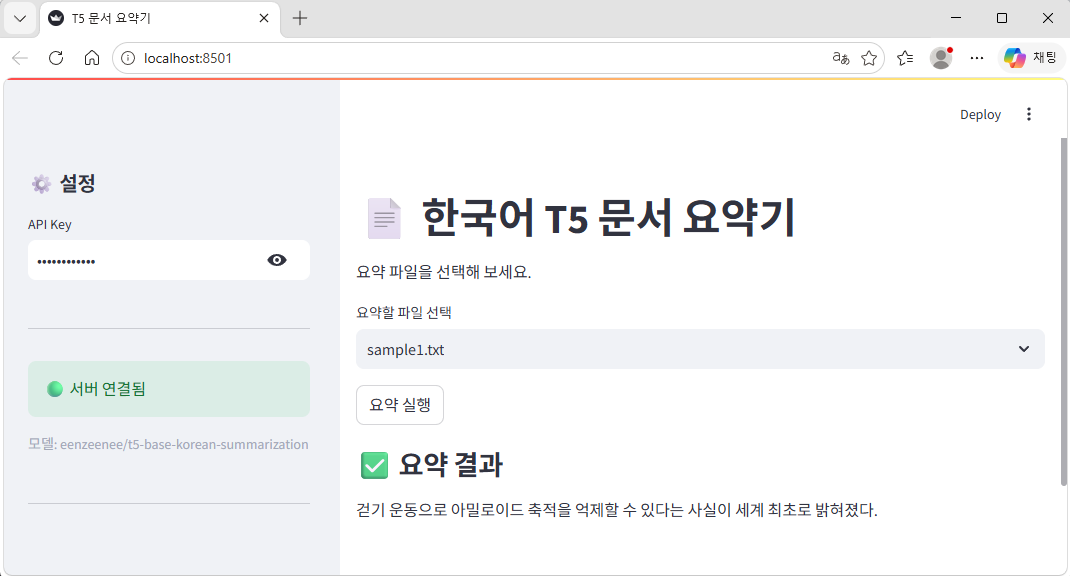

4. 구현하면서 가장 어려웠던 부분은?
   main 및 model_service 구현 부분으로 데이터를 잘 갖고오지 못했는데...오류 수정 및 이해를 좀더 할 수 있었습니다.

## 5.2 회고

스스로 돌아보기:
  - Day 1~7 교안 없이 코드를 작성할 수 있었는가?

    교안 내용을 기본으로 AI 도움으로 구현 했습니다.
      
  - 어떤 부분에서 교안을 다시 찾아봤는가?

    교안에 있는 main, service, app 코딩을 참고 했습니다.
    
  - 다음에 다시 만든다면 무엇을 다르게 하겠는가?

    서버에 있는 파일을 선택하도록 구현 했는데, 실질적인 서비스가 되기 위해서는 
    app에서 파일 내용을 서버로 보내서 요약하도록 변경해야 할것 같습니다.

## Day 8 최종 체크포인트

Q1. 본인의 프로젝트에서 Pydantic 검증은 어떤 잘못된 입력을 막아줍니까?

    - Pydantic은 런타임에 들어오는 데이터를 "타입이 틀린 값", "길이/범위를 넘는 값", "구조가 깨진 값",
        "커스텀 규칙을 위반한 값" 등을 검증하면서 잘못된 입력을 막아줍니다.
        예를들어 int 필드에 문자열 입력, 길이/범위가 벗어난 입력, list 필드에 list 타입이 아닌 입력,
        이 메일에 @ 없음 등 다양한 에러를 잡아냅니다.
        
Q2. Depends(verify_api_key)를 제거하면 어떤 위험이 있습니까?

    - Depends는 verify_api_key()를 먼저 실행해서 API Key 인증을 확인합니다.
    이를 제거하면 인증 절차가 없어져서 아래와 같은 위험이 있을 수 있습니다.
    
          - 서버다운 - 누군가의 초당 수백 건의 요청으로 인해 서버가 과부하되고 다운된다.
          - 비용 폭탄 - 불특정 다수의 요청으로 서버 사용량이 치솟습니다.
          - 모델 도용 - 공격자가 대량의 입력-출력 쌍을 수집함으로써 모델을 모방해서 학습합니다.
          - 추적 불가 - 에러 발생시 문제 원인을 파악하기 어렵고 악의적 사용자를 차단할 수 없습니다.
          
Q3. run_in_executor를 사용한 이유는 무엇입니까?

    - run_in_executor를 사용해서 이벤트 루프 블로킹을 방지합니다.
    이는 별도 thread를 만들어 요청을 처리하게 만들고, 다른 요청을 대기 가능해집니다.

Q4. Day 1~8 중 가장 많이 참고한 Day는 어디였습니까? 왜?

    - 7일차 교안을 많이 참고 했습니다. 오늘 과제와 비슷해서
    
Q5. 이 서비스를 실제로 배포하려면 추가로 무엇이 필요합니까?

    - 서비스를 배포하기 위해서는 프로덕션용 서버를 구축해야 하며, 컨테이너 운영 등 소스코딩 변경 부터
      운영 배포까지 전체적인 운영 환경 검토가 필요합니다.